In [1]:
import pandas as pd

In [3]:
df= pd.read_csv('Patient_Health_Records_5000.csv')
df.head()

,patient_id,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk
0,P00001,56.0,Female,North,27.29,114.31,180.54,95.35,0
1,P00002,69.0,Female,NaN,32.55,133.28,177.29,81.33,1
2,P00003,46.0,Female,North,31.55,124.43,NaN,135.49,1
3,P00004,32.0,Female,NaN,19.60,121.61,163.04,126.55,0
4,P00005,60.0,Female,North,21.89,126.25,250.47,158.93,1


In [4]:
df.describe()


,age,bmi,blood_pressure,cholesterol,glucose,disease_risk
count,4600.000000,4500.000000,5000.000000,4552.000000,4601.000000,5000.000000
mean,49.367826,26.955967,124.961126,200.722384,105.184897,0.355600
std,18.157938,5.073508,15.266972,35.871274,26.787027,0.478743
min,18.000000,8.000000,73.700000,43.250000,-6.640000,0.000000
25%,34.000000,23.597500,114.827500,176.677500,88.180000,0.000000
50%,50.000000,26.915000,124.870000,201.080000,104.700000,0.000000
75%,65.000000,30.350000,134.970000,224.492500,121.800000,1.000000
max,80.000000,70.000000,280.000000,600.000000,600.000000,1.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   patient_id      5000 non-null   object 
 1   age             4600 non-null   float64
 2   gender          4700 non-null   object 
 3   region          4750 non-null   object 
 4   bmi             4500 non-null   float64
 5   blood_pressure  5000 non-null   float64
 6   cholesterol     4552 non-null   float64
 7   glucose         4601 non-null   float64
 8   disease_risk    5000 non-null   int64  
dtypes: float64(5), int64(1), object(3)
memory usage: 351.7+ KB


In [7]:
df.shape

(5000, 9)

In [8]:
df.isnull().sum()

patient_id          0
age               400
gender            300
region            250
bmi               500
blood_pressure      0
cholesterol       448
glucose           399
disease_risk        0
dtype: int64

In [11]:
null_perc =(df.isnull().sum()/len(df))*100
print(null_perc)

patient_id         0.00
age                8.00
gender             6.00
region             5.00
bmi               10.00
blood_pressure     0.00
cholesterol        8.96
glucose            7.98
disease_risk       0.00
dtype: float64


In [13]:
num_cols =['age','bmi','blood_pressure','cholesterol','glucose']
cat_cols = ['gender','region']


In [14]:
from sklearn.impute import SimpleImputer
mean =SimpleImputer(strategy='mean')
df['age']=mean.fit_transform(df[['age']])



In [15]:
median = SimpleImputer(strategy="median")
df['bmi']=median.fit_transform(df[['bmi']])

In [22]:
from sklearn.impute import SimpleImputer

mode_imputer = SimpleImputer(strategy="most_frequent")

df["gender"] = mode_imputer.fit_transform(
    df[["gender"]]
)[:, 0]

df["region"] = mode_imputer.fit_transform(
    df[["region"]]
)[:, 0]

In [57]:
print(df["gender"].isnull().sum())
print(df["region"].isnull().sum())
print(df["age"].isnull().sum())
print(df["bmi"].isnull().sum())

0
0
0
0


In [24]:
df["chol_missing"] = (
    df["cholesterol"]
    .isnull()
    .astype(int)
)

In [25]:
random_samples = (
    df["cholesterol"]
    .dropna()
    .sample(
        df["cholesterol"]
        .isnull()
        .sum(),
        random_state=42
    )
)

df.loc[
    df["cholesterol"].isnull(),
    "cholesterol"
] = random_samples.values

In [ ]:
from sklearn.impute import KNNImputer
num_cols = [
    "age",
    "bmi",
    "blood_pressure",
    "cholesterol",
    "glucose"
]

knn = KNNImputer(
    n_neighbors=5
)

df[num_cols] = knn.fit_transform(
    df[num_cols]

)

In [35]:

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
mice = IterativeImputer(random_state=42)
df[num_cols] = mice.fit_transform(df[num_cols])

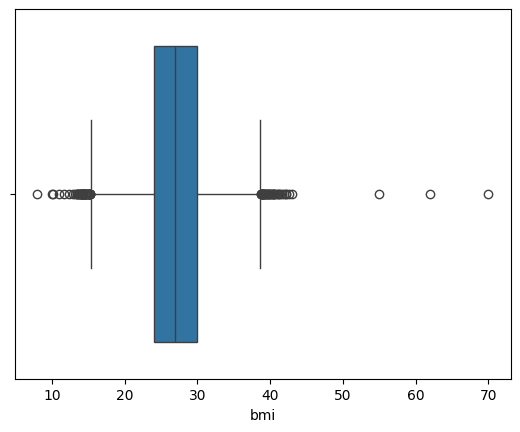

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(x=df["bmi"])
plt.show()

In [37]:
Q1 = df["bmi"].quantile(0.25)

Q3 = df["bmi"].quantile(0.75)

IQR = Q3 - Q1

In [38]:
lower_fence = (
    Q1 - 1.5 * IQR
)

upper_fence = (
    Q3 + 1.5 * IQR
)

In [39]:
outliers = df[(df["bmi"] < lower_fence)|(df["bmi"] > upper_fence)]
len(outliers)

88

In [50]:
print("Q1 =", Q1)
print("Q3 =", Q3)
print("IQR =", IQR)
print("Lower Fence =", lower_fence)
print("Upper Fence =", upper_fence)

Q1 = 24.06
Q3 = 29.8925
IQR = 5.8325
Lower Fence = 15.31125
Upper Fence = 38.64125


In [49]:
outliers = df[
    (df["bmi"] < lower_fence) |
    (df["bmi"] > upper_fence)
]

print("Number of Outliers =", len(outliers))

Number of Outliers = 0


In [44]:
print("Rows after removing outliers:", df.shape)

Rows after removing outliers: (4912, 10)


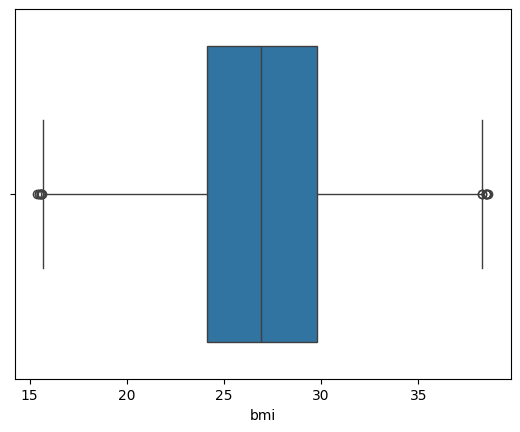

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df["bmi"])
plt.show()

In [56]:
from scipy import stats
import numpy as np
z_scores = np.abs(
    stats.zscore(df["bmi"])
)

df = df[
    z_scores < 3
]
print(z_scores)

[0.07599777 1.25827012 1.03350352 ... 0.94219495 0.01390887 0.37943269]


In [48]:
f = pd.get_dummies(
    df,
    columns=[
        "gender",
        "region"
    ],
    drop_first=True
)

In [51]:
print(df.shape)

print(df["bmi"].min())

print(df["bmi"].max())

(4912, 10)
15.4
38.6


In [52]:
from scipy import stats
import numpy as np

z_scores = np.abs(stats.zscore(df["cholesterol"]))

print("Max Z Score:", z_scores.max())

outliers_z = df[z_scores > 3]

print("Number of Cholesterol Outliers:", len(outliers_z))

Max Z Score: 11.166038819395599
Number of Cholesterol Outliers: 14


In [53]:
z_scores = np.abs(stats.zscore(df["cholesterol"]))

rows_before = len(df)

df = df[z_scores < 3]

rows_after = len(df)

print("Rows Before =", rows_before)
print("Rows After =", rows_after)
print("Rows Removed =", rows_before - rows_after)

Rows Before = 4912
Rows After = 4898
Rows Removed = 14


In [55]:
lower = df["blood_pressure"].quantile(0.01)

upper = df["blood_pressure"].quantile(0.99)

print("Lower Percentile =", lower)
print("Upper Percentile =", upper)

Lower Percentile = 90.4988
Upper Percentile = 160.30569999999997
